# Classification: Price Category
Classify cars as cheap (0), medium (1), or expensive (2).

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('classification_features.csv')
X, y = df.drop(columns=['price_category']), df['price_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(y_train.value_counts().sort_index().rename({0:'cheap',1:'medium',2:'expensive'}))

Train: (597524, 7), Test: (149382, 7)
price_category
cheap        199175
medium       199230
expensive    199119
Name: count, dtype: int64


In [7]:
results = {}

def evaluate(name, y_pred):
    acc = accuracy_score(y_test, y_pred) * 100
    f1  = f1_score(y_test, y_pred, average='macro') * 100
    results[name] = {'Accuracy%': round(acc, 2), 'F1-macro%': round(f1, 2)}
    print(f'{name:<35} Accuracy: {acc:.2f}%   F1-macro: {f1:.2f}%')

In [8]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
lr.fit(X_train_sc, y_train)
evaluate('Logistic Regression', lr.predict(X_test_sc))

Logistic Regression                 Accuracy: 70.99%   F1-macro: 71.03%


In [9]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=25, min_samples_leaf=3,
    max_features='sqrt', n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)
evaluate('Random Forest', rf.predict(X_test))

Random Forest                       Accuracy: 88.08%   F1-macro: 88.10%


In [10]:
xgb_model = xgb.XGBClassifier(
    n_estimators=3000, learning_rate=0.03, max_depth=7,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, min_child_weight=5,
    random_state=42, n_jobs=-1, verbosity=0,
    early_stopping_rounds=50, eval_metric='mlogloss'
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
evaluate('XGBoost', xgb_model.predict(X_test))
print(f'  Best iteration: {xgb_model.best_iteration}')

XGBoost                             Accuracy: 88.34%   F1-macro: 88.37%
  Best iteration: 2999


In [11]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=3000, learning_rate=0.03, max_depth=8,
    num_leaves=127, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,
    random_state=42, n_jobs=-1, verbosity=-1
)
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
evaluate('LightGBM', lgb_model.predict(X_test))
print(f'  Best iteration: {lgb_model.best_iteration_}')

LightGBM                            Accuracy: 88.40%   F1-macro: 88.42%
  Best iteration: 2605


In [12]:
et = ExtraTreesClassifier(
    n_estimators=200, max_depth=25, min_samples_leaf=3,
    max_features='sqrt', n_jobs=-1, random_state=42
)
et.fit(X_train, y_train)
evaluate('Extra Trees', et.predict(X_test))

Extra Trees                         Accuracy: 87.80%   F1-macro: 87.79%


In [13]:
results_df = pd.DataFrame(results).T.sort_values('Accuracy%', ascending=False)
print(results_df.to_string())
best = results_df.index[0]
print(f'\nBest model: {best}')

                     Accuracy%  F1-macro%
LightGBM                 88.40      88.42
XGBoost                  88.34      88.37
Random Forest            88.08      88.10
Extra Trees              87.80      87.79
Logistic Regression      70.99      71.03

Best model: LightGBM


              precision    recall  f1-score   support

       Cheap       0.92      0.91      0.91     49794
      Medium       0.82      0.84      0.83     49808
   Expensive       0.92      0.91      0.91     49780

    accuracy                           0.88    149382
   macro avg       0.88      0.88      0.88    149382
weighted avg       0.88      0.88      0.88    149382



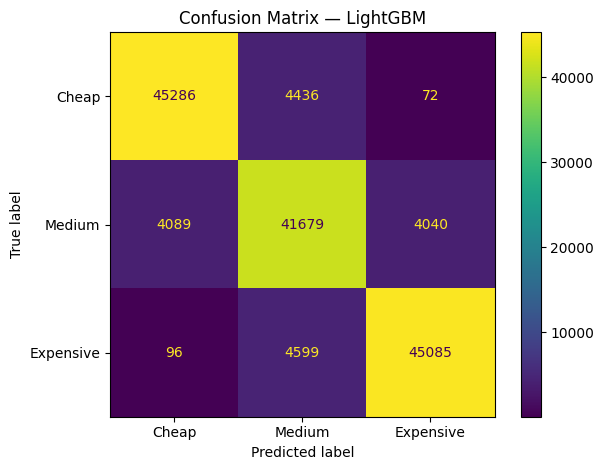

In [14]:
best_models = {
    'Logistic Regression': (lr, X_test_sc),
    'Random Forest':       (rf, X_test),
    'XGBoost':             (xgb_model, X_test),
    'LightGBM':            (lgb_model, X_test),
    'Extra Trees':         (et, X_test),
}
best_model, best_X = best_models[best]
best_pred = best_model.predict(best_X)

print(classification_report(y_test, best_pred, target_names=['Cheap', 'Medium', 'Expensive']))

ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, display_labels=['Cheap', 'Medium', 'Expensive']
)
plt.title(f'Confusion Matrix — {best}')
plt.tight_layout()
plt.show()